# LMI Morhan

In [23]:
# Import Path to handle the raster path
from pathlib import Path

# Import NumPy for numerical array operations
import numpy as np

# Import Matplotlib for plotting
import matplotlib.pyplot as plt

# Help to create a nice colorbar
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as mticker

# Formatter without scientific notation
formatter = mticker.FuncFormatter(lambda x, pos: f"{int(x):,}")

# Import RasterIO to read the raster data
import rasterio as rio

# Import plotting_extent to display the raster in map coordinates
from rasterio.plot import plotting_extent

import geopandas as gpd
from scipy import ndimage
from shapely.geometry import box
from shapely.ops import unary_union

# Import raster polygonization utilities
import rasterio.features as rfeatures

from shapely.geometry import shape

In [24]:
#%% Paths
# =======
bathy_path = "../data/gifford_bathy.tif"

#%% Raster reading
# ----------------
with rio.open(bathy_path) as dataset:
    bathy = dataset.read(1, masked=True).astype(float).filled(np.nan)
    transform = dataset.transform
    crs = dataset.crs
    height = dataset.height
    width = dataset.width

extent = plotting_extent(bathy, transform)

dx = abs(transform.a)
dy = abs(transform.e)

print("shape:", bathy.shape)
print("crs:", crs)
print("cell size (resolution):", (dx, dy))
print("depth range:", (np.nanmin(bathy), np.nanmax(bathy)))
print("extent:", extent)

shape: (835, 914)
crs: EPSG:32757
cell size (resolution): (50.0, 50.0)
depth range: (np.float64(-3221.864990234375), np.float64(-255.59681701660156))
extent: (515475.0, 561175.0, 7026925.0, 7068675.0)


In [25]:
tpi = bathy
finite_tpi = np.isfinite(bathy)
finite_tpi

threshold = np.nanmean(bathy)
threshold

mask_high = finite_tpi & (bathy > threshold)
mask_low = finite_tpi & (bathy <= threshold)
print("Candidate pixels:", int(mask_high.sum()))
print("Candidate pixels:", int(mask_low.sum()))

Candidate pixels: 305561
Candidate pixels: 447633


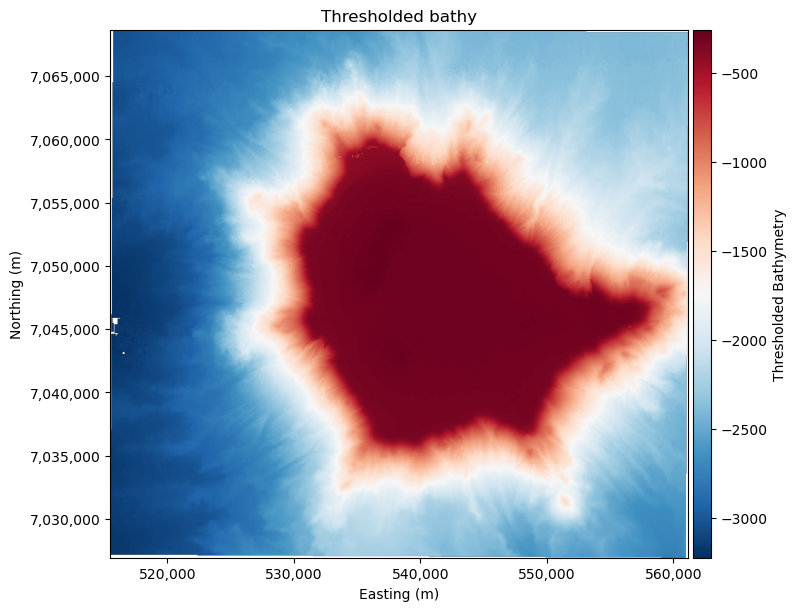

In [26]:
# TPI Visualization
# -----------------
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

im = ax.imshow(
    tpi,
    extent=extent,
    origin="upper",
    cmap="RdBu_r",
)

ax.set_title("Thresholded bathy")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Thresholded Bathymetry")

plt.show()

In [27]:
## Local Moran's I (LMI)

In [28]:
#%% LMI / Moran helper functions
# ------------------------------

DEFAULT_LMI_WEIGHTS_3X3 = np.array(
    [
        [0.707, 1.000, 0.707],
        [1.000, 0.000, 1.000],
        [0.707, 1.000, 0.707],
    ],
    dtype=float,
)


def local_morans_i_raster(
    bathy_for_lmi,
    weights=DEFAULT_LMI_WEIGHTS_3X3,
    valid_mask=None,
    ddof=0,
):
    """
    Calculate a Local Moran's I raster.

    Parameters
    ----------
    bathy_for_lmi : np.ndarray
        Bathymetry/elevation raster used for LMI.
        Use np.nan for nodata and for cells that should be excluded.

    weights : np.ndarray
        Neighbourhood weight matrix. The default is the GA-SaMMT-style 3x3 kernel.

    valid_mask : np.ndarray or None
        Boolean mask where True means valid input cell.
        If None, finite cells in bathy_for_lmi are used.

    ddof : int
        Delta degrees of freedom for standard deviation.

    Returns
    -------
    lmi : np.ndarray
        Local Moran's I raster. Invalid cells are np.nan.

    stats : dict
        Mean, standard deviation, and variance used in the LMI calculation.
    """
    bathy_for_lmi = np.asarray(bathy_for_lmi, dtype=float)

    if valid_mask is None:
        valid_mask = np.isfinite(bathy_for_lmi)
    else:
        valid_mask = valid_mask & np.isfinite(bathy_for_lmi)

    if not np.any(valid_mask):
        raise ValueError("No valid cells available for Local Moran's I calculation.")

    valid_values = bathy_for_lmi[valid_mask]
    mean_bathy = np.nanmean(valid_values)
    std_bathy = np.nanstd(valid_values, ddof=ddof)

    if not np.isfinite(std_bathy) or std_bathy == 0:
        raise ValueError("Bathymetry standard deviation is zero or invalid.")

    variance_bathy = std_bathy**2

    z = bathy_for_lmi - mean_bathy

    # Focal SUM with nodata ignored.
    # For a weighted sum, nodata neighbours can be treated as zero centred values.
    z_for_sum = np.where(valid_mask, z, 0.0)

    focal_weighted_sum = ndimage.convolve(
        z_for_sum,
        weights,
        mode="constant",
        cval=0.0,
    )

    lmi = (z / variance_bathy) * focal_weighted_sum
    lmi[~valid_mask] = np.nan

    stats = {
        "mean_bathy": mean_bathy,
        "std_bathy": std_bathy,
        "variance_bathy": variance_bathy,
    }

    return lmi, stats


def threshold_lmi(lmi, C_lmi=1.0, valid_mask=None, ddof=0):
    """
    Threshold the LMI raster using:

        threshold = mean(LMI) + C_lmi * std(LMI)

    Returns a boolean mask where LMI >= threshold.
    """
    lmi = np.asarray(lmi, dtype=float)

    if valid_mask is None:
        valid_mask = np.isfinite(lmi)
    else:
        valid_mask = valid_mask & np.isfinite(lmi)

    if not np.any(valid_mask):
        raise ValueError("No valid LMI cells available for thresholding.")

    mean_lmi = np.nanmean(lmi[valid_mask])
    std_lmi = np.nanstd(lmi[valid_mask], ddof=ddof)
    threshold = mean_lmi + C_lmi * std_lmi

    lmi_mask = np.zeros(lmi.shape, dtype=bool)
    lmi_mask[valid_mask] = lmi[valid_mask] >= threshold

    stats = {
        "mean_lmi": mean_lmi,
        "std_lmi": std_lmi,
        "threshold_lmi": threshold,
    }

    return lmi_mask, threshold, stats


def keep_lmi_components_touching_core(lmi_mask, core_mask, connectivity=8):
    """
    Keep only LMI connected components that touch the TPI/core high mask.

    In the ArcGIS workflow this is similar to selecting LMI polygons by spatial
    relationship to the extracted TPI-core polygons.
    """
    if connectivity == 8:
        structure = np.ones((3, 3), dtype=int)
    elif connectivity == 4:
        structure = np.array(
            [
                [0, 1, 0],
                [1, 1, 1],
                [0, 1, 0],
            ],
            dtype=int,
        )
    else:
        raise ValueError("connectivity must be 4 or 8")

    labels, n_labels = ndimage.label(lmi_mask, structure=structure)

    # Because the core cells have been masked out before LMI, an LMI component
    # will usually touch the core rather than overlap it.
    core_touch_zone = ndimage.binary_dilation(core_mask, structure=structure)

    selected = np.zeros_like(lmi_mask, dtype=bool)

    for label_id in range(1, n_labels + 1):
        component = labels == label_id

        if np.any(component & core_touch_zone):
            selected |= component

    return selected


def polygonize_mask(mask, transform, crs, area_threshold=0.0):
    """
    Polygonize a boolean raster mask and optionally filter by area.
    """
    shapes_iter = rfeatures.shapes(
        mask.astype(np.uint8),
        mask=mask,
        transform=transform,
    )

    geoms = [shape(geom) for geom, val in shapes_iter if val == 1]
    gdf = gpd.GeoDataFrame(geometry=geoms, crs=crs)

    if len(gdf):
        gdf["area"] = gdf.geometry.area
        gdf = gdf[gdf["area"] > area_threshold].copy()
    else:
        gdf["area"] = []

    return gdf

In [29]:
#%% Run the LMI / Moran extension
# -------------------------------

# Treat the existing mask_high as the TPI/core high mask.
tpi_core_mask = mask_high.copy()

# If your bathymetry is depth-positive-down, uncomment the next line.
# bathy_lmi_source = -bathy

# If your bathymetry is elevation-positive-up, use it directly.
bathy_lmi_source = bathy.copy()

# Remove the TPI/core high cells before calculating LMI.
bathy_for_lmi = bathy_lmi_source.copy()
bathy_for_lmi[tpi_core_mask] = np.nan

valid_for_lmi = np.isfinite(bathy_for_lmi)

# LMI STD Scale parameter. The GA-SaMMT tutorial uses 1.0.
C_lmi = 1.0

lmi, lmi_bathy_stats = local_morans_i_raster(
    bathy_for_lmi,
    weights=DEFAULT_LMI_WEIGHTS_3X3,
    valid_mask=valid_for_lmi,
)

lmi_mask_all, lmi_threshold, lmi_stats = threshold_lmi(
    lmi,
    C_lmi=C_lmi,
)

# Keep only LMI patches touching the TPI/core high mask.
lmi_mask_selected = keep_lmi_components_touching_core(
    lmi_mask_all,
    tpi_core_mask,
    connectivity=8,
)

# Expanded high mask = TPI/core + selected LMI extension.
expanded_high_mask = tpi_core_mask | lmi_mask_selected

print("LMI bathymetry stats:", lmi_bathy_stats)
print("LMI stats:", lmi_stats)
print("LMI threshold:", lmi_threshold)
print("All LMI selected pixels:", int(lmi_mask_all.sum()))
print("LMI pixels touching TPI core:", int(lmi_mask_selected.sum()))
print("Expanded high pixels:", int(expanded_high_mask.sum()))

LMI bathymetry stats: {'mean_bathy': np.float64(-2537.906769686677), 'std_bathy': np.float64(375.43005826002974), 'variance_bathy': np.float64(140947.72864512933)}
LMI stats: {'mean_lmi': np.float64(6.7448096331869944), 'std_lmi': np.float64(5.921010506008284), 'threshold_lmi': np.float64(12.66582013919528)}
LMI threshold: 12.66582013919528
All LMI selected pixels: 86025
LMI pixels touching TPI core: 37553
Expanded high pixels: 343114


In [31]:
#%% Polygonize the expanded TPI + LMI result
# ------------------------------------------

gdf_lmi_all = polygonize_mask(
    lmi_mask_selected,
    transform=transform,
    crs=crs,
    area_threshold=0.0,
)

area_threshold = 45

gdf_expanded_high = polygonize_mask(
    expanded_high_mask,
    transform=transform,
    crs=crs,
    area_threshold=area_threshold,
)

print("Selected LMI polygons:", len(gdf_lmi_all))
print("Expanded high polygons after area filtering:", len(gdf_expanded_high))

Selected LMI polygons: 3
Expanded high polygons after area filtering: 3


## LMI visualisation

The four panels below show:

1. The starting TPI/core high mask.
2. The bathymetry after the core cells are masked out for LMI.
3. The LMI raster with the threshold shown in the title.
4. The final expanded high mask, combining the TPI/core mask and selected LMI patches.

In [34]:
def hillshade(
    bathy,
    transform,
    z_factor=1.0,
    azimuth_deg=315.0,
    altitude_deg=45.0,
    invert_bathy=False,
):
    # Pixel sizes. This also works for rotated affine transforms.
    dx = np.hypot(transform.a, transform.d)
    dy = np.hypot(transform.b, transform.e)

    if dx == 0 or dy == 0:
        raise ValueError("Invalid transform: pixel size cannot be zero.")

    surface = bathy.astype(float)

    if invert_bathy:
        surface = -surface

    surface = surface * z_factor

    dz_dy, dz_dx = np.gradient(surface, dy, dx)

    slope = np.arctan(np.hypot(dz_dx, dz_dy))
    aspect = np.arctan2(dz_dy, -dz_dx)

    az = np.deg2rad(360.0 - azimuth_deg + 90.0)
    alt = np.deg2rad(altitude_deg)

    shade = (
        np.sin(alt) * np.cos(slope)
        + np.cos(alt) * np.sin(slope) * np.cos(az - aspect)
    )

    hs = 255.0 * np.clip(shade, 0.0, 1.0)

    hs[np.isnan(bathy)] = np.nan

    return hs
    
hs = hillshade(bathy,transform)

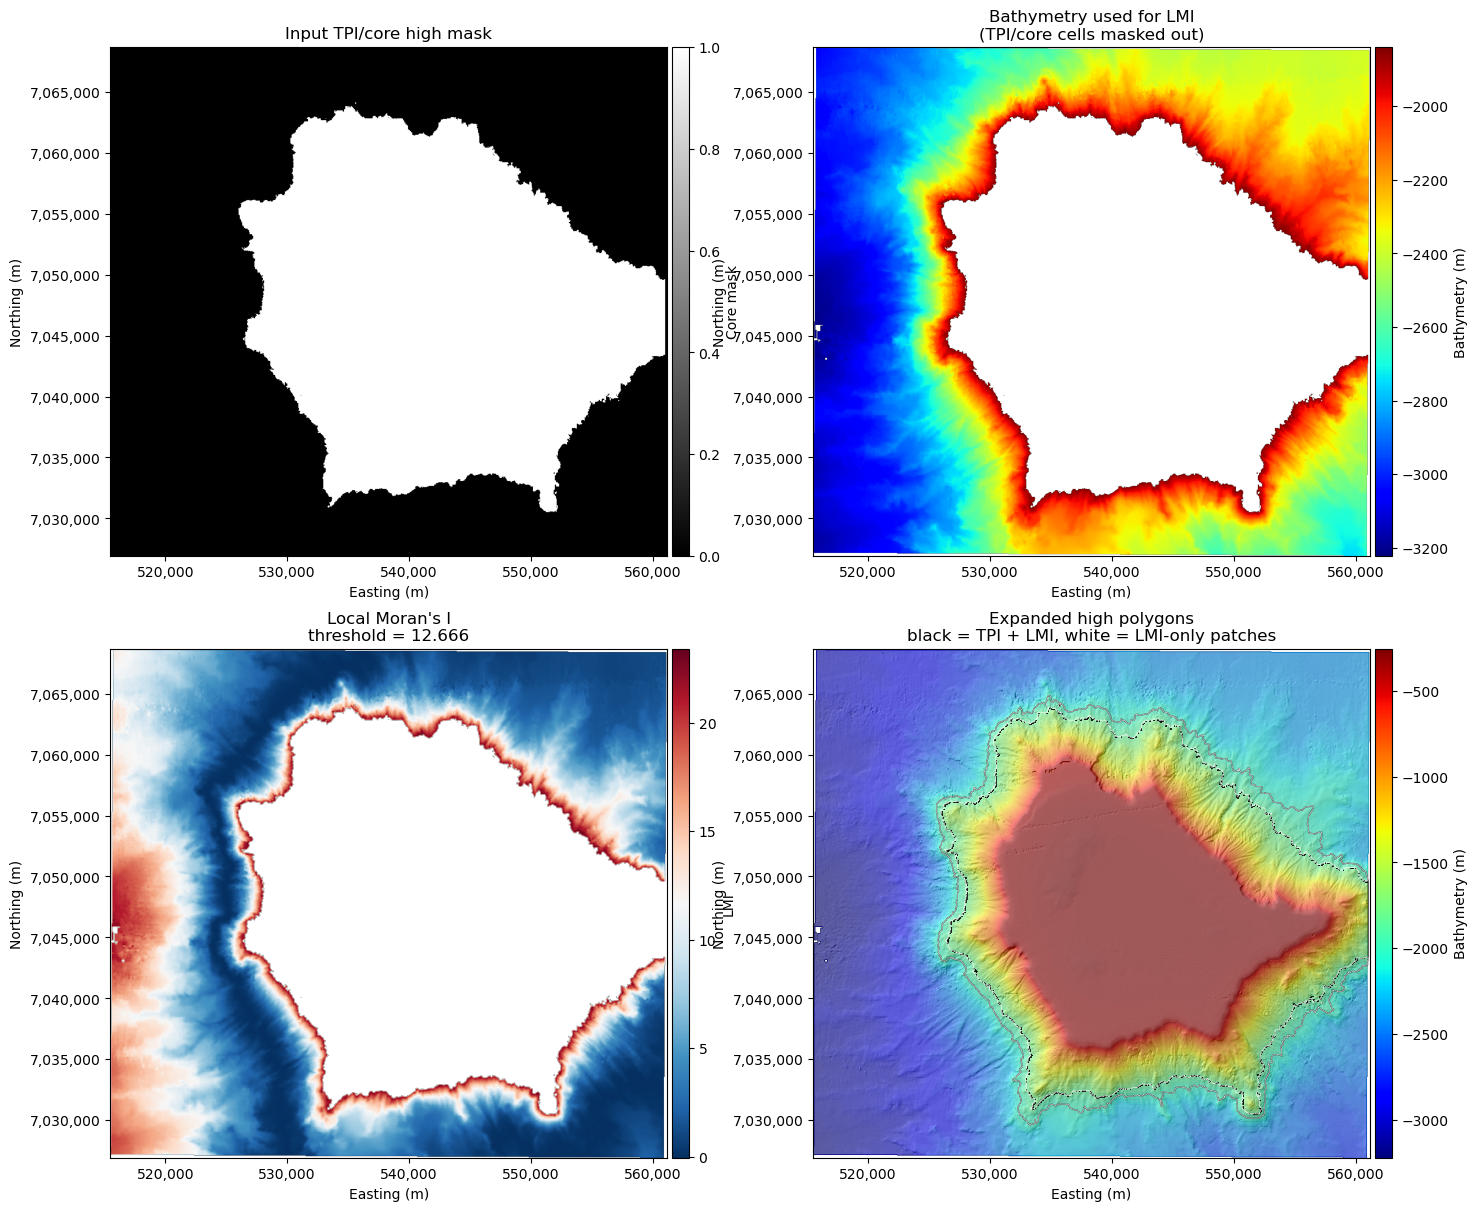

In [35]:
#%% LMI Visualization
# -------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

# 1. TPI/core mask
ax = axes[0, 0]
im = ax.imshow(
    tpi_core_mask.astype(float),
    extent=extent,
    origin="upper",
    cmap="gray",
    vmin=0,
    vmax=1,
)
ax.set_title("Input TPI/core high mask")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)
fig.colorbar(im, cax=cax, label="Core mask")

# 2. Bathymetry used for LMI
ax = axes[0, 1]
im = ax.imshow(
    bathy_for_lmi,
    extent=extent,
    origin="upper",
    cmap="jet",
)
ax.set_title("Bathymetry used for LMI\n(TPI/core cells masked out)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)
fig.colorbar(im, cax=cax, label="Bathymetry (m)")

# 3. LMI raster
ax = axes[1, 0]
im = ax.imshow(
    lmi,
    extent=extent,
    origin="upper",
    cmap="RdBu_r",
)
ax.set_title(f"Local Moran's I\nthreshold = {lmi_threshold:.3f}")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)
fig.colorbar(im, cax=cax, label="LMI")

# 4. Expanded high mask on bathymetry
ax = axes[1, 1]
im = ax.imshow(
    bathy,
    extent=extent,
    origin="upper",
    cmap="jet",
)
ax.imshow(
    hs,
    extent=extent,
    origin="upper",
    cmap="gray",
    alpha=0.5,
)

if len(gdf_expanded_high):
    gdf_expanded_high.boundary.plot(ax=ax, color="black", linewidth=0.7, alpha=0.9)

if len(gdf_lmi_all):
    gdf_lmi_all.boundary.plot(ax=ax, color="white", linewidth=0.5, alpha=0.8)

ax.set_title("Expanded high polygons\nblack = TPI + LMI, white = LMI-only patches")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)
fig.colorbar(im, cax=cax, label="Bathymetry (m)")

plt.show()

In [37]:
#%% LMI threshold mask
# --------------------
finite_lmi = np.isfinite(lmi)

# If lmi_threshold already exists, use it.
# Otherwise compute it here.
if "lmi_threshold" not in globals():
    C_lmi = 1.0
    lmi_mean = np.nanmean(lmi[finite_lmi])
    lmi_std = np.nanstd(lmi[finite_lmi])
    lmi_threshold = lmi_mean + C_lmi * lmi_std

# GA-SaMMT-style threshold:
# keep strong positive Local Moran's I values
lmi_mask = finite_lmi & (lmi >= lmi_threshold)

print("LMI mean:", np.nanmean(lmi[finite_lmi]))
print("LMI std:", np.nanstd(lmi[finite_lmi]))
print("LMI threshold:", lmi_threshold)
print("LMI pixels:", int(lmi_mask.sum()))

LMI mean: 6.7448096331869944
LMI std: 5.921010506008284
LMI threshold: 12.66582013919528
LMI pixels: 86025


In [38]:
#%% Keep only LMI components touching the TPI/core mask
# -----------------------------------------------------
from scipy import ndimage

def keep_components_touching_core(mask, core_mask, connectivity=8):
    if connectivity == 8:
        structure = np.ones((3, 3), dtype=int)
    else:
        structure = np.array(
            [
                [0, 1, 0],
                [1, 1, 1],
                [0, 1, 0],
            ],
            dtype=int,
        )

    labels, n_labels = ndimage.label(mask, structure=structure)

    selected = np.zeros(mask.shape, dtype=bool)

    for label_id in range(1, n_labels + 1):
        component = labels == label_id

        if np.any(component & tpi_core_mask):
            selected |= component

    return selected


selected_lmi_mask = keep_components_touching_core(
    lmi_mask,
    tpi_core_mask,
    connectivity=8,
)

expanded_high_mask = tpi_core_mask | selected_lmi_mask

print("Selected LMI pixels:", int(selected_lmi_mask.sum()))
print("Expanded high pixels:", int(expanded_high_mask.sum()))

Selected LMI pixels: 0
Expanded high pixels: 305561


In [40]:
def mask_to_gdf(mask, transform, crs, value=1, area_threshold=None):
    """
    Polygonise a boolean mask into a GeoDataFrame.

    Parameters
    ----------
    mask : 2D bool array
        True cells become polygons.

    transform : rasterio Affine
        Raster geotransform.

    crs : rasterio CRS
        Coordinate reference system.

    value : int
        Burn value used for polygonisation.

    area_threshold : float or None
        Optional minimum polygon area in CRS units squared.

    Returns
    -------
    gdf : geopandas.GeoDataFrame
    """
    mask_uint8 = mask.astype("uint8")

    shapes = rfeatures.shapes(
        mask_uint8,
        mask=mask,
        transform=transform,
    )

    geoms = [shape(geom) for geom, val in shapes if val == value]

    gdf = gpd.GeoDataFrame(geometry=geoms, crs=crs)

    if len(gdf) == 0:
        gdf["area_m2"] = []
        return gdf

    gdf["area_m2"] = gdf.geometry.area

    if area_threshold is not None:
        gdf = gdf[gdf["area_m2"] >= area_threshold].copy()

    return gdf

In [41]:
#%% Polygonise expanded high mask
# -------------------------------
gdf_expanded_high = mask_to_gdf(
    expanded_high_mask,
    transform=transform,
    crs=crs,
    area_threshold=area_threshold,
)

gdf_lmi_all = mask_to_gdf(
    lmi_mask,
    transform=transform,
    crs=crs,
    area_threshold=area_threshold,
)

print("Expanded high polygons:", len(gdf_expanded_high))
print("All LMI polygons:", len(gdf_lmi_all))

Expanded high polygons: 22
All LMI polygons: 17


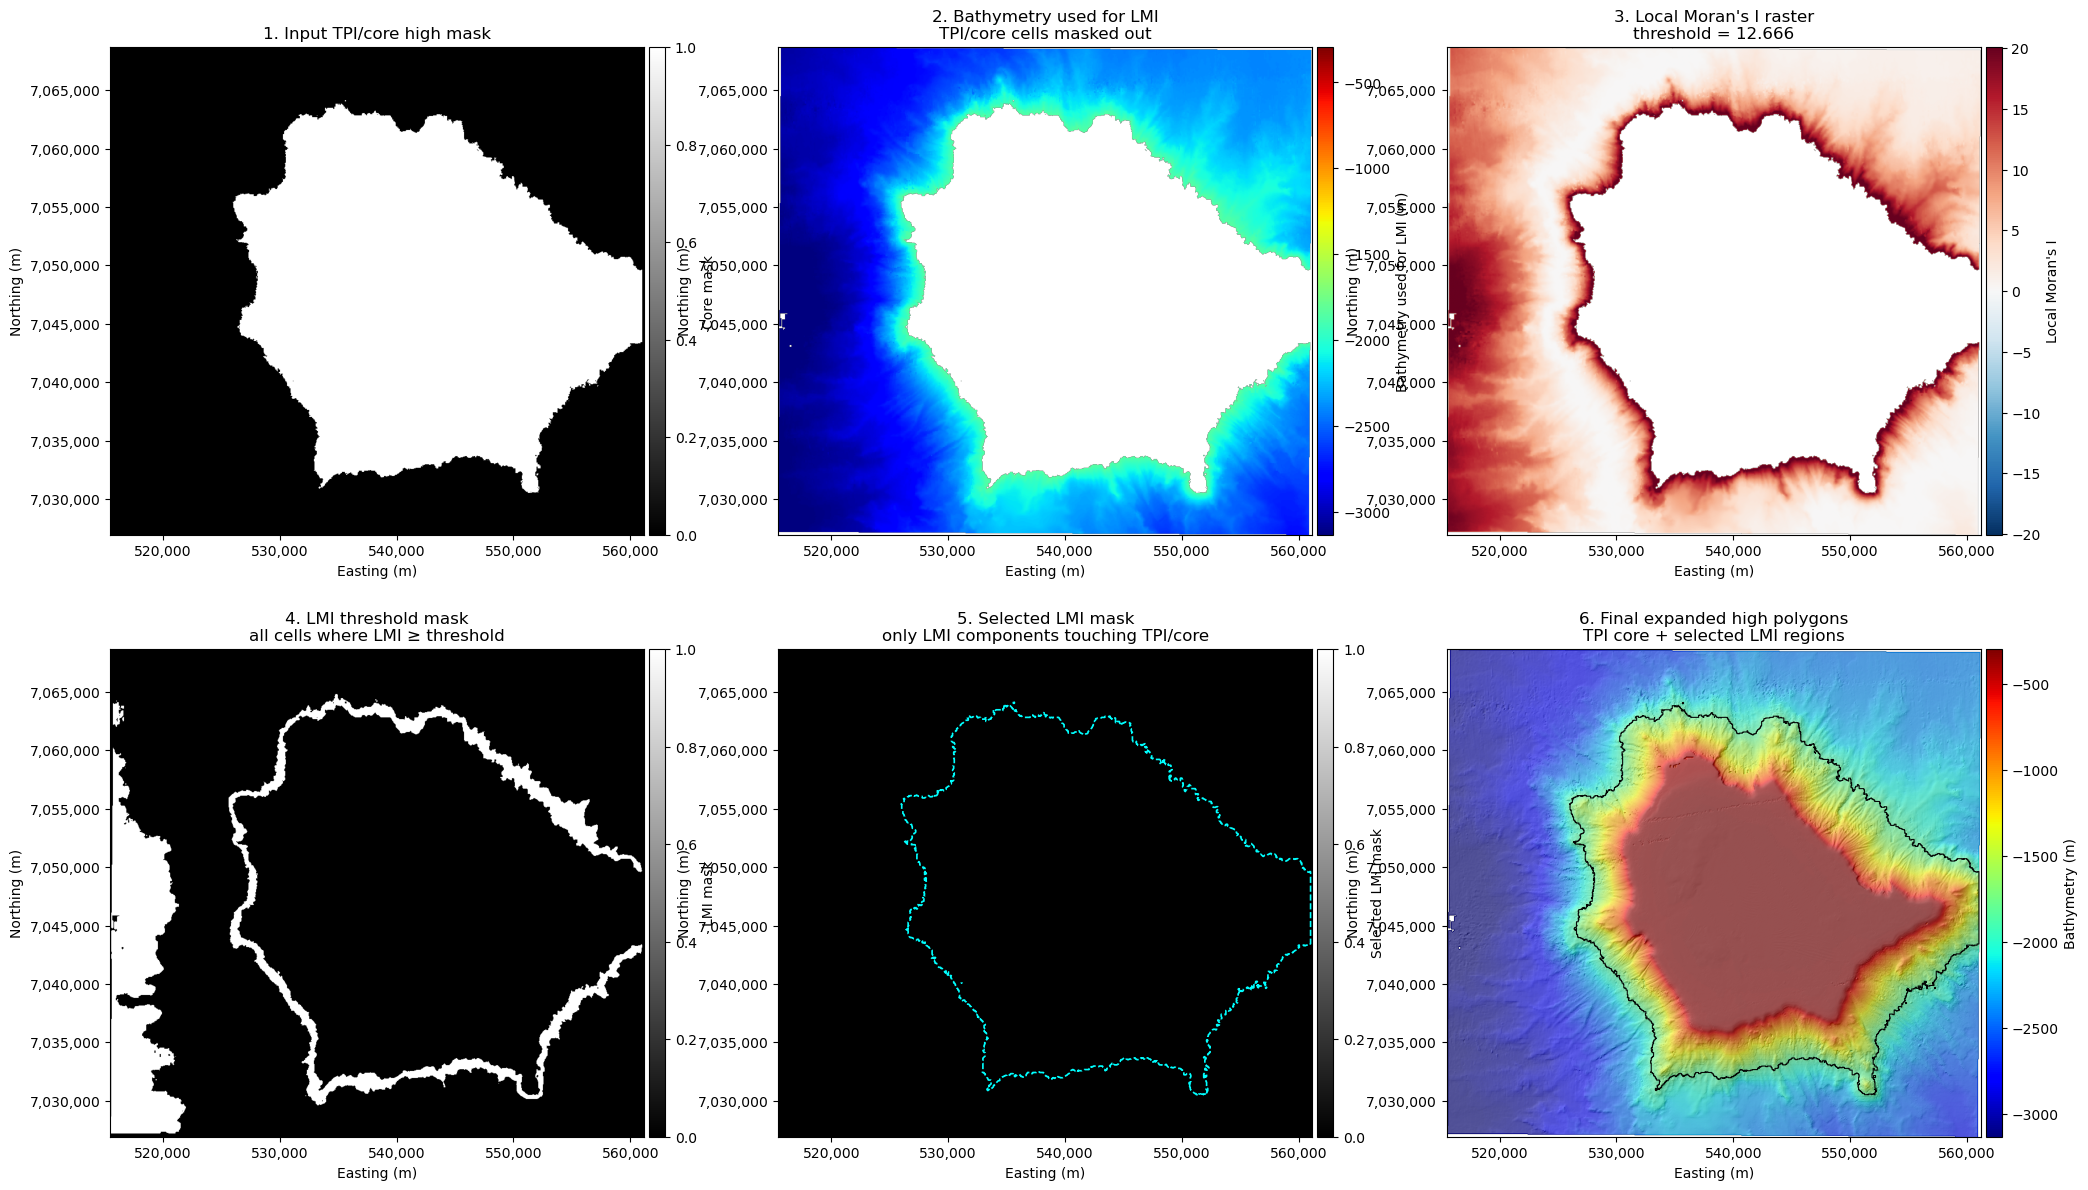

In [45]:
#%% LMI Visualization - challenged/improved
# -----------------------------------------
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(2, 3, figsize=(20, 12), constrained_layout=True)

# Robust LMI colour scale centred on zero
lmi_abs = np.nanpercentile(np.abs(lmi), 98)
norm_lmi = TwoSlopeNorm(vmin=-lmi_abs, vcenter=0, vmax=lmi_abs)

# Robust bathymetry colour scale
bathy_vmin, bathy_vmax = np.nanpercentile(bathy, [2, 98])

# ---------------------------------------------------------------------
# 1. Input TPI/core mask
# ---------------------------------------------------------------------
ax = axes[0, 0]

im = ax.imshow(
    tpi_core_mask.astype(float),
    extent=extent,
    origin="upper",
    cmap="gray",
    vmin=0,
    vmax=1,
)

ax.set_title("1. Input TPI/core high mask")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)
fig.colorbar(im, cax=cax, label="Core mask")


# ---------------------------------------------------------------------
# 2. Bathymetry used for LMI
# ---------------------------------------------------------------------
ax = axes[0, 1]

im = ax.imshow(
    bathy_for_lmi,
    extent=extent,
    origin="upper",
    cmap="jet",
    vmin=bathy_vmin,
    vmax=bathy_vmax,
)

# Overlay original TPI core boundary if available
if "gdf_core" in globals() and len(gdf_core):
    gdf_core.boundary.plot(ax=ax, color="black", linewidth=0.8)

ax.set_title("2. Bathymetry used for LMI\nTPI/core cells masked out")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)
fig.colorbar(im, cax=cax, label="Bathymetry used for LMI (m)")


# ---------------------------------------------------------------------
# 3. LMI raster
# ---------------------------------------------------------------------
ax = axes[0, 2]

im = ax.imshow(
    lmi,
    extent=extent,
    origin="upper",
    cmap="RdBu_r",
    norm=norm_lmi,
)

ax.set_title(f"3. Local Moran's I raster\nthreshold = {lmi_threshold:.3f}")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)
fig.colorbar(im, cax=cax, label="Local Moran's I")


# ---------------------------------------------------------------------
# 4. Thresholded LMI mask
# ---------------------------------------------------------------------
ax = axes[1, 0]

im = ax.imshow(
    lmi_mask.astype(float),
    extent=extent,
    origin="upper",
    cmap="gray",
    vmin=0,
    vmax=1,
)

ax.set_title("4. LMI threshold mask\nall cells where LMI ≥ threshold")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)
fig.colorbar(im, cax=cax, label="LMI mask")


# ---------------------------------------------------------------------
# 5. Selected LMI mask
# ---------------------------------------------------------------------
ax = axes[1, 1]

im = ax.imshow(
    selected_lmi_mask.astype(float),
    extent=extent,
    origin="upper",
    cmap="gray",
    vmin=0,
    vmax=1,
)

# Overlay TPI core for context
# ax.contour(
#     tpi_core_mask.astype(float),
#     levels=[0.5],
#     extent=extent,
#     origin="upper",
#     linewidths=0.8,
# )
ax.contour(
    tpi_core_mask.astype(float),
    levels=[0.5],
    extent=extent,
    origin="upper",
    colors="cyan",
    linewidths=1.2,
    linestyles="--",
)

ax.set_title("5. Selected LMI mask\nonly LMI components touching TPI/core")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)
fig.colorbar(im, cax=cax, label="Selected LMI mask")


# ---------------------------------------------------------------------
# 6. Final expanded high polygons
# ---------------------------------------------------------------------
ax = axes[1, 2]

im = ax.imshow(
    bathy,
    extent=extent,
    origin="upper",
    cmap="jet",
    vmin=bathy_vmin,
    vmax=bathy_vmax,
)

ax.imshow(
    hs,
    extent=extent,
    origin="upper",
    cmap="gray",
    alpha=0.45,
)

if len(gdf_expanded_high):
    gdf_expanded_high.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8,
        alpha=0.95,
    )

ax.set_title("6. Final expanded high polygons\nTPI core + selected LMI regions")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)
fig.colorbar(im, cax=cax, label="Bathymetry (m)")

plt.show()